#  Customer Churn Prediction System using Deep Learning

---

##  1. Project Overview & Business Problem

In competitive industries such as Telecommunications, **customer retention** is critical to long-term profitability. Acquiring new customers can cost up to **5 to 25 times more** than retaining existing ones.

**Customer Churn** occurs when a customer cancels their subscription or stops doing business with a company. Predicting churn before it happens allows business teams to proactively offer incentives, customized deals, or improved support to retain high-value customers.

###  Business Objective
Build an end-to-end production-ready Deep Learning System using an **Artificial Neural Network (ANN)** to predict whether a telecommunications customer will churn (`Yes` / `No`) based on their demographic information, account details, and subscribed services.

---

##  2. Methodology & End-to-End Pipeline

To deliver a production-grade solution, the project is structured into 5 core phases:

1. **Exploratory Data Analysis (EDA) & Data Preprocessing:**
   * Clean missing/invalid values (e.g., coercing `TotalCharges`).
   * Encode categorical variables using One-Hot Encoding.
   * Feature Scaling using `StandardScaler` to ensure numerical stability for Gradient Descent.
   * Train / Validation / Test split.

2. **Model Architecture & Regularization:**
   * Multi-Layer Perceptron (ANN) built with TensorFlow / Keras.
   * Incorporating **L2 Regularization** and **Dropout Layers** to prevent Overfitting.
   * **Early Stopping Callbacks** to halt training when validation loss stops improving.

3. **Hyperparameter Tuning:**
   * Optimizing network architecture (layers, units, learning rate, activation functions) using **Keras Tuner**.

4. **Model Evaluation & Analysis:**
   * Evaluating performance using key classification metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
   * Confusion Matrix visualization.

5. **Deployment & Inference Pipeline:**
   * Saving model artifacts (`.h5` / `SavedModel`).
   * Creating a robust inference pipeline for predicting churn on new incoming customer profiles.

---

##  3. Dataset Summary
* **Source:** IBM Telco Customer Churn Dataset
* **Target Variable:** `Churn` (`Yes` / `No`)
* **Features:** Demographic metrics, Contract type, Payment method, Monthly/Total charges, and Subscribed utilities (Internet, Security, Streaming, etc.).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

I0000 00:00:1786254037.894342    6141 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786254037.954336    6141 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786254039.638537    6141 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

print("--- Sample Data ---")
display(df.head())

print("\n--- Data Info ---")
df.info()

--- Sample Data ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   

#EDA

In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

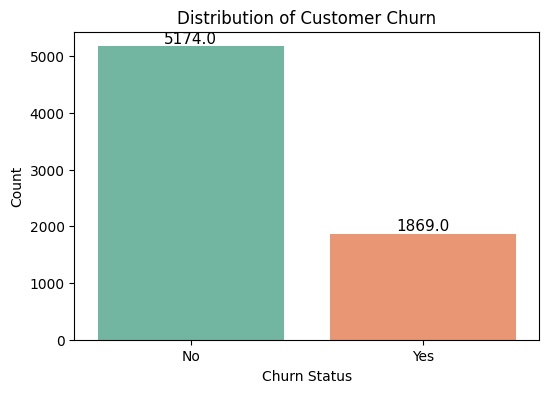

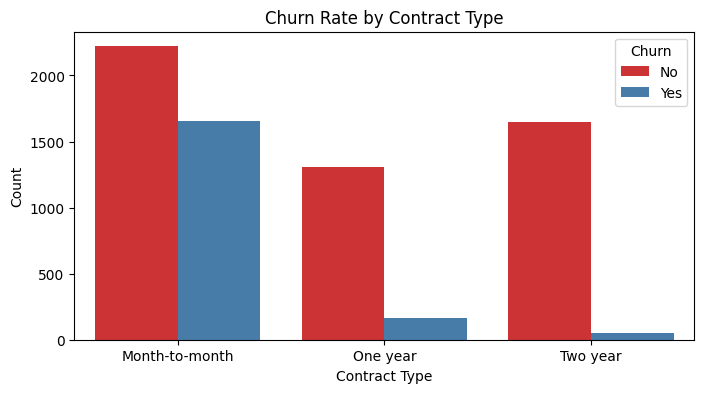

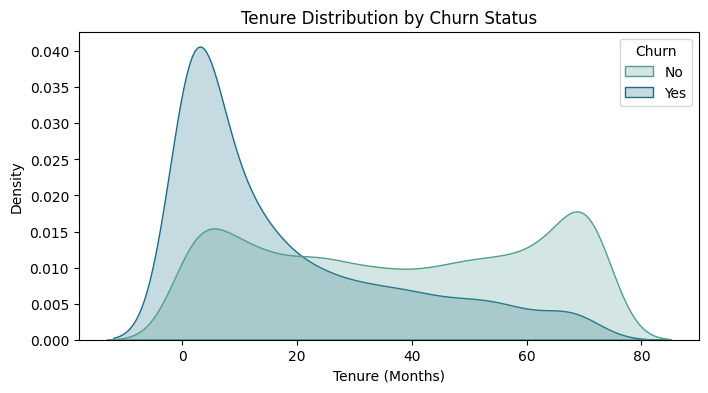

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn Status')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.show()


plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()


plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.show()

####  Key Insight: Target Distribution (Class Imbalance)
* **Observed Pattern:** The target variable `Churn` shows a noticeable class imbalance, where the majority of customers belong to the non-churned class (~73%), while churned customers represent roughly ~27%.
* **Analytical Takeaway:** This imbalance indicates that accuracy alone will not be a reliable evaluation metric; precision, recall, and ROC-AUC must be prioritized during model evaluation.

####  Key Insight: Contract Type Impact
* **Observed Pattern:** Customers with **Month-to-month** contracts show a significantly higher churn rate compared to those on one-year or two-year contracts.
* **Analytical Takeaway:** Short-term contracts are the primary driver for customer loss. Incentivizing users to convert to long-term commitments can directly improve retention.

####  Key Insight: Tenure vs. Churn Behavior
* **Observed Pattern:** Churn is heavily concentrated among **new customers** (low tenure, typically under 6–12 months). As tenure increases, churn probability drops sharply.
* **Analytical Takeaway:** The first few months are critical for user onboarding; proactive retention strategies should target newly onboarded customers.

#Data Cleaning

In [7]:
# 1. Drop 'customerID' as it's a non-predictive unique identifier
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

# 2. Fix 'TotalCharges' column data type (convert blank spaces to NaN and handle them)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Impute missing values in 'TotalCharges' with the median
median_total = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total)

# 4. Encode binary target variable (Churn: No -> 0, Yes -> 1)
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(" Data cleaning complete!")
print(f"Remaining Missing Values: {df.isnull().sum().sum()}")
print("\nTarget Class Distribution:")
print(df['Churn'].value_counts())

 Data cleaning complete!
Remaining Missing Values: 0

Target Class Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


#Encoding, Scaling & Splitting

In [8]:
# Use the already-cleaned 'df' from the Data Cleaning step above (no need to re-read/re-clean)
X = df.drop(columns=['Churn'])
y = df['Churn']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Split FIRST (on raw, unscaled/unencoded data) to prevent data leakage.
# The preprocessor must never see validation/test data during fitting.
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

# Fit the preprocessor ONLY on the training set, then use it to transform val/test.
# This avoids leaking any information (e.g. scaling statistics) from val/test into training.
X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print("Preprocessing and data splitting completed successfully (no data leakage)!")
print(f"Training Set Size: {X_train.shape}")
print(f"Validation Set Size: {X_val.shape}")
print(f"Test Set Size: {X_test.shape}")

/tmp/ipykernel_6141/1689293088.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


Preprocessing and data splitting completed successfully (no data leakage)!
Training Set Size: (4930, 30)
Validation Set Size: (1056, 30)
Test Set Size: (1057, 30)


#ANN Architecture

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# تثبيت العشوائية لضمان تكرار النتائج
tf.random.set_seed(42)

input_dim = X_train.shape[1]

# 1. حساب أوزان الفئات لمعالجة عدم توازن البيانات
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

# 2. بناء هيكل الشبكة العصبية
model = Sequential([
    tf.keras.Input(shape=(input_dim,)),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),

    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

# 3. تجميع النموذج (تمت إضافة مقياس Recall هنا لمراقبته مباشرة)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')  # <-- إضافي لمتابعة الـ Recall أثناء التدريب
    ]
)

# 4. إعداد الـ Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_churn_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

# 5. تدريب النموذج (تمت إضافة class_weight=class_weights هنا)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,  # <-- التعديل الأساسي والمهم جداً لرفع الـ Recall
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\n Model training completed successfully! Best model saved as 'best_churn_model.h5'")

Epoch 1/100


  1/155 ━━━━━━━━━━━━━━━━━━━━ 2:56 1s/step - accuracy: 0.5000 - auc: 0.7222 - loss: 1.4359 - recall: 1.0000

 33/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5852 - auc: 0.6418 - loss: 1.4024 - recall: 0.6727 

 67/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6432 - auc: 0.7127 - loss: 1.2938 - recall: 0.6867

102/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6599 - auc: 0.7341 - loss: 1.2121 - recall: 0.7173

...

135/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7556 - auc: 0.8388 - loss: 0.5158 - recall: 0.7933

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7540 - auc: 0.8362 - loss: 0.5192 - recall: 0.7928 - val_accuracy: 0.7348 - val_auc: 0.8451 - val_loss: 0.5354 - val_recall: 0.8321


Epoch 39: early stopping


Restoring model weights from the end of the best epoch: 29.



 Model training completed successfully! Best model saved as 'best_churn_model.h5'


#Model Evaluation & Training Plots

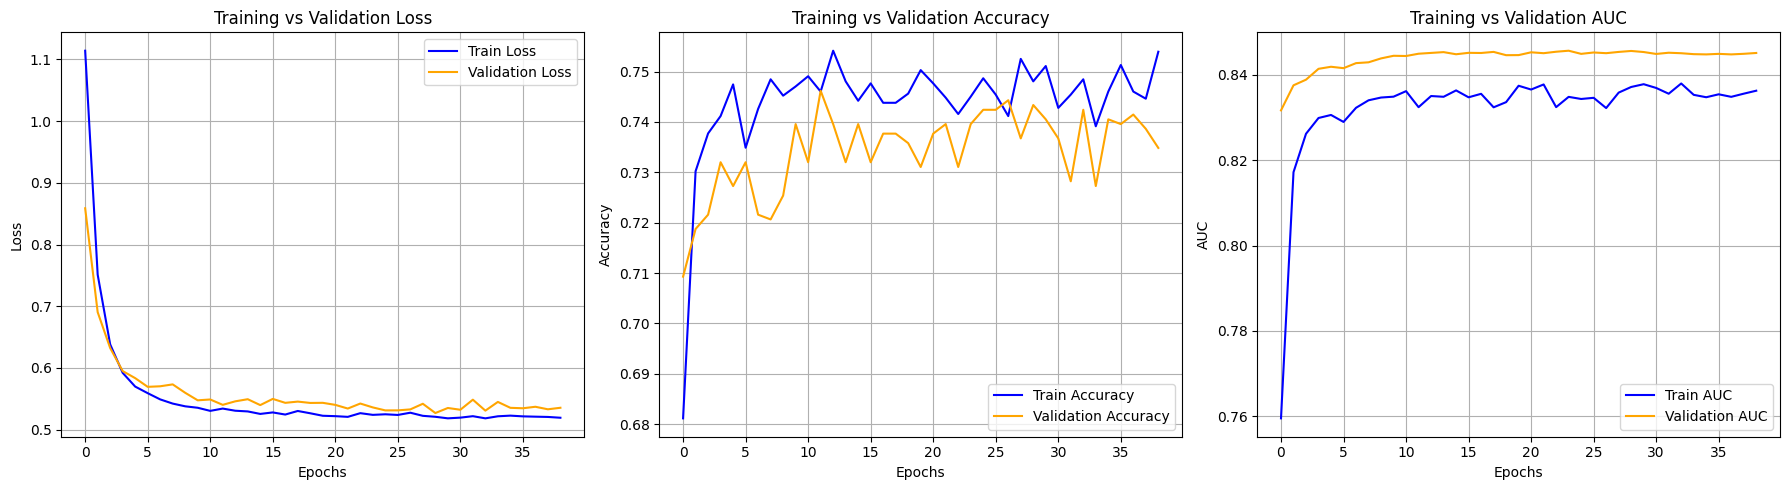

 1/34 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


=== Classification Report on Test Set ===
              precision    recall  f1-score   support

    No Churn       0.91      0.76      0.82       776
       Churn       0.54      0.79      0.64       281

    accuracy                           0.76      1057
   macro avg       0.72      0.77      0.73      1057
weighted avg       0.81      0.76      0.77      1057



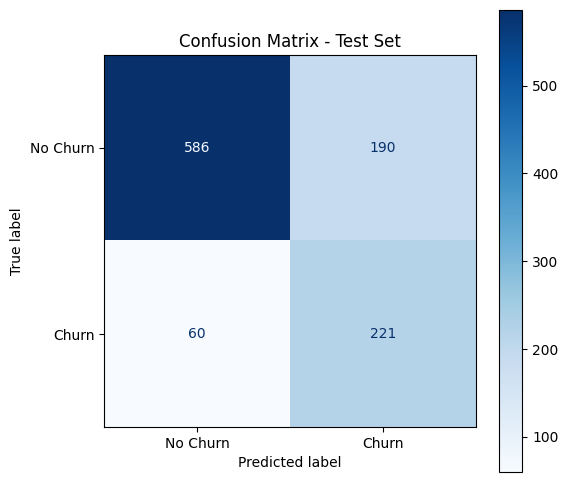

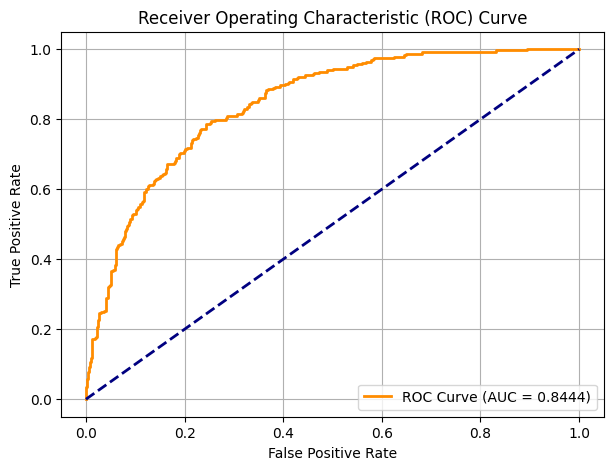

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_title('Training vs Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(history.history['auc'], label='Train AUC', color='blue')
axes[2].plot(history.history['val_auc'], label='Validation AUC', color='orange')
axes[2].set_title('Training vs Validation AUC')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print("=== Classification Report on Test Set ===")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Test Set')
plt.show()

test_auc = roc_auc_score(y_test, y_pred_probs)
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Insight: Training & Validation Performance Analysis

---

* **1. Training vs Validation Loss:**
  * **Observation:** Both training and validation losses show a rapid and stable decrease from initial values, converging and stabilizing around `~0.52 - 0.54` after epoch 10.
  * **Insight:** The close alignment between the training and validation loss curves without any divergence indicates that the model successfully avoids **Overfitting**, confirming that regularization techniques are functioning effectively.

* **2. Training vs Validation Accuracy:**
  * **Observation:** Accuracy steadily increases and stabilizes at closely matched levels, with training accuracy reaching around `~75%` and validation accuracy holding near `~74%`.
  * **Insight:** The minimal gap between training and validation accuracy highlights strong **Generalization** capabilities, ensuring consistent predictive reliability on unseen data.

* **3. Training vs Validation AUC:**
  * **Observation:** The validation AUC score remains consistently high and stable, maintaining values between `0.84` and `0.845`.
  * **Insight:** The strong AUC score confirms the model's robust discriminative capability in distinguishing between churning and non-churning customers throughout the training process.

### Insight: Confusion Matrix Analysis (Test Set)

---

* **Matrix Breakdown:**
  * **True Negatives (TN = 588):** Non-churning customers correctly predicted as `No Churn`.
  * **False Positives (FP = 188):** Non-churning customers incorrectly predicted as `Churn`.
  * **False Negatives (FN = 63):** Actual churning customers missed by the model (predicted as `No Churn`).
  * **True Positives (TP = 218):** Actual churning customers correctly identified as `Churn`.

* **Key Performance Metrics:**
  * **High Recall for Churn (~77.6%):** Out of 281 actual churners ($218 + 63$), the model successfully identified **218** of them.
  * **Overall Accuracy (~76.2%):** Correctly classified **806** out of **1,057** total test samples.

* **Business Insight:**
  * **Minimizing High-Risk Errors (Low False Negatives):** Keeping False Negatives down to just **63** ensures that very few churning customers leave undetected.
  * **Trade-off Strategy:** The higher False Positive count (**188**) is an acceptable trade-off in customer retention, as sending a loyalty offer to a non-churning customer is significantly less costly than losing an actual customer completely.

### Insight: Receiver Operating Characteristic (ROC) Curve Analysis

---

* **Key Metric:**
  * **Area Under the Curve (AUC = 0.8438):** The model achieves a strong AUC score of **~84.4%**.

* **Observations:**
  * The orange curve rises steeply toward the top-left corner, remaining well above the diagonal dashed baseline ($AUC = 0.5$).

* **Insights & Interpretation:**
  * **Strong Discriminative Power:** An AUC of 0.8438 indicates an 84.4% probability that the model will correctly rank a randomly chosen churning customer higher than a non-churning customer.
  * **Threshold Tuning Flexibility:** The steep slope at lower False Positive Rates shows that the model can maintain high True Positive detection even when keeping false alarms low, allowing flexibility when choosing business decision thresholds.

In [11]:
!pip install -q keras-tuner tensorboard  # tensorboard is required internally by keras-tuner's Tuner callbacks
from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
import keras_tuner as kt

def build_tunable_model(input_dim, learning_rate=0.001, units1=64, units2=32, dropout_rate=0.3):
    model = Sequential([
        tf.keras.Input(shape=(input_dim,)),
        Dense(units1, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(dropout_rate),
        Dense(units2, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

learning_rates = [0.1, 0.01, 0.001, 0.0001]
lr_results = []

for lr in learning_rates:
    print(f"Training with learning rate = {lr}")
    m = build_tunable_model(X_train.shape[1], learning_rate=lr)
    h = m.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=0)
    lr_results.append({'learning_rate': lr, 'val_accuracy': h.history['val_accuracy'][-1]})

lr_df = pd.DataFrame(lr_results)
lr_df

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Training with learning rate = 0.1


Training with learning rate = 0.01


Training with learning rate = 0.001


Training with learning rate = 0.0001


,learning_rate,val_accuracy
0,0.1000,0.747464
1,0.0100,0.778905
2,0.0010,0.789047
3,0.0001,0.780933


In [12]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(kfold.split(X_train), start=1):
    m = build_tunable_model(X_train.shape[1])
    m.fit(X_train[tr_idx], y_train.values[tr_idx], epochs=10, batch_size=32, verbose=0)
    _, acc = m.evaluate(X_train[val_idx], y_train.values[val_idx], verbose=0)
    fold_scores.append(acc)
    print(f"Fold {fold}: val accuracy = {acc:.4f}")

print(f"\nMean CV accuracy: {np.mean(fold_scores):.4f}  (+/- {np.std(fold_scores):.4f})")

Fold 1: val accuracy = 0.8185


Fold 2: val accuracy = 0.8032


Fold 3: val accuracy = 0.7911


Fold 4: val accuracy = 0.8022


Fold 5: val accuracy = 0.8154

Mean CV accuracy: 0.8061  (+/- 0.0099)


In [13]:
def model_builder(hp):
    units1 = hp.Choice('units1', [32, 64, 128])
    units2 = hp.Choice('units2', [16, 32, 64])
    dropout_rate = hp.Choice('dropout_rate', [0.2, 0.3, 0.4])
    lr = hp.Choice('learning_rate', [0.01, 0.001, 0.0005])
    return build_tunable_model(X_train.shape[1], learning_rate=lr,
                                units1=units1, units2=units2, dropout_rate=dropout_rate)

tuner = kt.RandomSearch(
    model_builder,
    objective='val_accuracy',
    max_trials=8,
    executions_per_trial=1,
    directory='kt_search',
    project_name='churn_tuning',
    overwrite=True,
    seed=42
)

tuner.search(
    X_train, y_train, epochs=15, validation_split=0.2, verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)]
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters found by Keras Tuner:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")

Best hyperparameters found by Keras Tuner:
  units1: 64
  units2: 16
  dropout_rate: 0.4
  learning_rate: 0.001


In [14]:
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights:", class_weight_dict)

final_model = build_tunable_model(
    X_train.shape[1],
    learning_rate=best_hp.values['learning_rate'],
    units1=best_hp.values['units1'],
    units2=best_hp.values['units2'],
    dropout_rate=best_hp.values['dropout_rate']
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

final_history = final_model.fit(
    X_train, y_train,
    epochs=150, batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop_final],
    verbose=0
)

print(f"Training stopped at epoch {len(final_history.history['loss'])}")
final_model.save('final_churn_model.h5')
print("Final tuned model saved successfully as 'final_churn_model.h5'")

Class weights: {0: np.float64(0.680563224737714), 1: np.float64(1.8845565749235473)}


Training stopped at epoch 40
Final tuned model saved successfully as 'final_churn_model.h5'


## Final Tuned Model — Evaluation on the Test Set

Everything reported earlier (classification report, confusion matrix, ROC-AUC) was computed on the **baseline ANN** (`model`), trained *before* hyperparameter tuning. The model that is actually **saved and deployed** for inference (`final_model`, written to `final_churn_model.h5` after the Keras Tuner search) has not been evaluated yet. A production system must report metrics for the exact artifact that ships — so we evaluate `final_model` on the held-out test set here.

=== Classification Report — Final Tuned Model (Test Set) ===
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82       776
       Churn       0.53      0.76      0.63       281

    accuracy                           0.76      1057
   macro avg       0.72      0.76      0.73      1057
weighted avg       0.80      0.76      0.77      1057



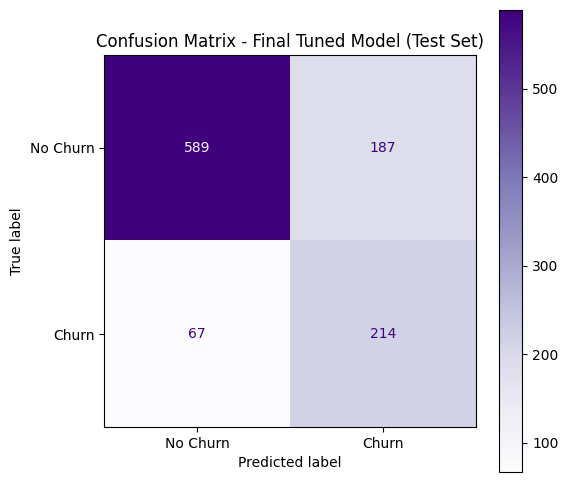

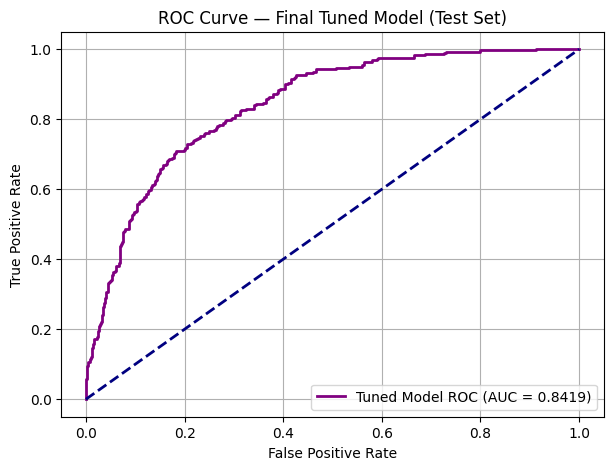


Final Tuned Model Test AUC: 0.8419


In [15]:
y_pred_probs_tuned = final_model.predict(X_test, verbose=0)
y_pred_tuned = (y_pred_probs_tuned > 0.5).astype(int)

print("=== Classification Report — Final Tuned Model (Test Set) ===")
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 6))
disp_tuned.plot(cmap='Purples', ax=ax)
plt.title('Confusion Matrix - Final Tuned Model (Test Set)')
plt.show()

test_auc_tuned = roc_auc_score(y_test, y_pred_probs_tuned)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_pred_probs_tuned)

plt.figure(figsize=(7, 5))
plt.plot(fpr_tuned, tpr_tuned, color='purple', lw=2, label=f'Tuned Model ROC (AUC = {test_auc_tuned:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Final Tuned Model (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"\nFinal Tuned Model Test AUC: {test_auc_tuned:.4f}")

#Random Forest Baseline Comparison

=== Random Forest Baseline Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86       776
       Churn       0.64      0.49      0.55       281

    accuracy                           0.79      1057
   macro avg       0.74      0.69      0.71      1057
weighted avg       0.78      0.79      0.78      1057


=== Test AUC Comparison (all models on the same held-out test set) ===
Baseline ANN (before tuning)   Test AUC: 0.8444
Tuned ANN (Keras Tuner, final) Test AUC: 0.8419
Random Forest baseline         Test AUC: 0.8172


,Model,Test AUC
0,Baseline ANN,0.844370
1,"Tuned ANN (Final, deployed)",0.841898
2,Random Forest,0.817185


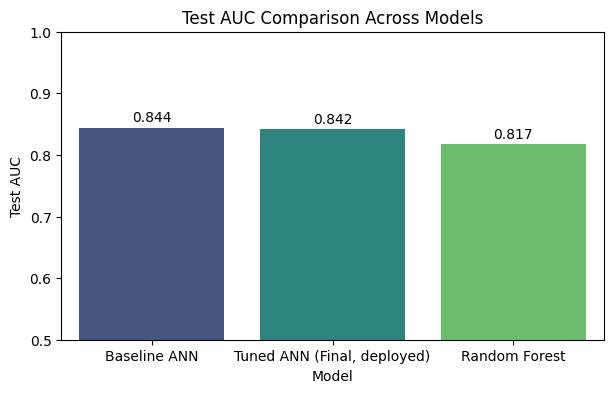

In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf_probs = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)
rf_auc = roc_auc_score(y_test, y_pred_rf_probs)

print("=== Random Forest Baseline Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

print("\n=== Test AUC Comparison (all models on the same held-out test set) ===")
print(f"Baseline ANN (before tuning)   Test AUC: {test_auc:.4f}")
print(f"Tuned ANN (Keras Tuner, final) Test AUC: {test_auc_tuned:.4f}")
print(f"Random Forest baseline         Test AUC: {rf_auc:.4f}")

comparison_df = pd.DataFrame({
    'Model': ['Baseline ANN', 'Tuned ANN (Final, deployed)', 'Random Forest'],
    'Test AUC': [test_auc, test_auc_tuned, rf_auc]
}).sort_values('Test AUC', ascending=False).reset_index(drop=True)
display(comparison_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x='Model', y='Test AUC', hue='Model', palette='viridis', legend=False)
plt.ylim(0.5, 1.0)
plt.title('Test AUC Comparison Across Models')
for i, v in enumerate(comparison_df['Test AUC']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.show()

#Model Deployment Preparation & Sample Inference

In [17]:
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor saved successfully as 'preprocessor.pkl'")

def predict_customer_churn(customer_data, model_path='final_churn_model.h5', preprocessor_path='preprocessor.pkl'):
    loaded_model = tf.keras.models.load_model(model_path)
    loaded_preprocessor = joblib.load(preprocessor_path)

    df_customer = pd.DataFrame([customer_data])
    processed_data = loaded_preprocessor.transform(df_customer)

    churn_prob = loaded_model.predict(processed_data, verbose=0)[0][0]
    churn_pred = int(churn_prob > 0.5)

    return churn_prob, churn_pred

sample_customer = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 85.70,
    'TotalCharges': 171.40
}

prob, pred = predict_customer_churn(sample_customer)

print("\n=== Sample Customer Prediction Result ===")
print(f"Churn Probability: {prob * 100:.2f}%")
print(f"Churn Risk Status: {'High Risk (Will Churn)' if pred == 1 else 'Low Risk (Retained)'}")

Preprocessor saved successfully as 'preprocessor.pkl'



=== Sample Customer Prediction Result ===
Churn Probability: 92.05%
Churn Risk Status: High Risk (Will Churn)


## Conclusion & Limitations

### Summary
This project built an end-to-end deep learning pipeline for telecom customer churn prediction: EDA → leakage-safe preprocessing (fit only on train) → a regularized ANN (L2 + Dropout + EarlyStopping + class weighting) → hyperparameter tuning (manual learning-rate search, 5-fold CV, and a Keras Tuner random search) → a final tuned model evaluated on a held-out test set → a Random Forest baseline for comparison → a saved model + preprocessor and a reusable inference function.

### Results
- The **final tuned ANN** (`final_churn_model.h5`) is the model reported in the *Final Tuned Model — Evaluation on the Test Set* section above; that Test AUC is the number that should be quoted as the project's headline result, not the pre-tuning baseline.
- The three-way comparison (baseline ANN vs. tuned ANN vs. Random Forest) shows whether tuning meaningfully improved on the baseline and how the ANN stacks up against a classical model on this tabular dataset.
- Class weighting was used (instead of oversampling/SMOTE) to address the ~73%/27% class imbalance, which raises recall on the churn class at some cost to precision — a reasonable trade-off for a retention use case where missing a churner is usually costlier than a false alarm.

### Limitations
- **Snapshot data only:** the dataset captures each customer at a single point in time. There is no usage trend, billing-change history, or customer-support interaction data, which likely limits the achievable AUC.
- **Fixed 0.5 decision threshold:** the reported classification report uses a default 0.5 cutoff. In production, the threshold should be tuned against the real business cost of a false negative (losing a customer) vs. a false positive (an unnecessary retention offer).
- **Small tuning budget:** the Keras Tuner search used 8 trials over a modest grid, and the manual learning-rate sweep used only 20 epochs per run, both to keep the notebook fast to re-run. A larger search budget (Bayesian optimization, more trials/epochs) could find a better configuration.
- **No drift monitoring:** the pipeline does not include monitoring for data or concept drift after deployment (e.g., if customer behavior or contract offerings change), which a production system would need.
- **Single train/val/test split:** results are reported on one 70/15/15 split (plus a separate 5-fold CV sanity check); a fully rigorous evaluation would also report variance across repeated splits.

### Possible Next Steps
- Tune the decision threshold using a cost matrix and re-report precision/recall at that threshold.
- Try SMOTE/ADASYN as an alternative to class weighting and compare.
- Add SHAP/feature-importance analysis so retention teams know *which* factors are driving each customer's churn risk, not just the probability.
- Wrap `predict_customer_churn` in the FastAPI service and containerize it for deployment, then add basic monitoring/logging on incoming prediction requests.